## Segmentation Models Comparative Analysis

In [43]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import scienceplots
plt.style.use(['science',"no-latex"])

In [44]:
# 1. Define Paths using pathlib
DATA_DIR = Path().cwd().parents[1] / "data" / "metrics"
OUTPUT_DIR = Path("./segmentation-models-visualizations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [45]:
# Load the segmentation dataset
csv_path = DATA_DIR / "segmentation_models.csv"
df_seg = pd.read_csv(csv_path)

# Sort models by performance metric for clearer charting
df = df_seg.sort_values(by="validationMeanIoU", ascending=True)

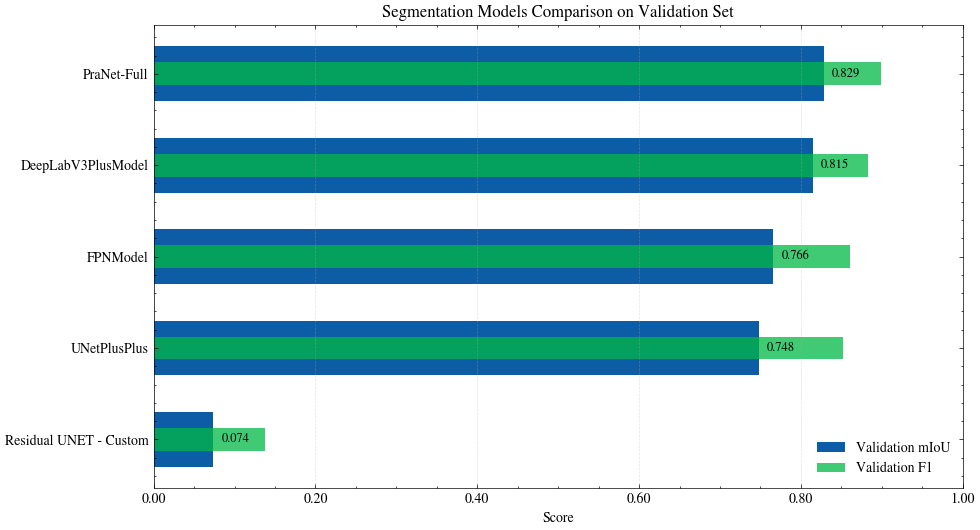

In [46]:
fig, ax = plt.subplots(figsize=(10, 5.5))

y = np.arange(len(df))
bars = ax.barh(y, df["validationMeanIoU"], height=0.6, label="Validation mIoU")
ax.barh(y, df["validationF1Score"], height=0.25, label="Validation F1", alpha=0.75)

ax.set_yticks(y)
ax.set_yticklabels(df["modelName"])
ax.set_xlabel("Score")
ax.set_title("Segmentation Models Comparison on Validation Set")
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(loc="lower right")

for i, v in enumerate(df["validationMeanIoU"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "segmentation_models_ranked_validation_miou.png", bbox_inches="tight")
plt.show()

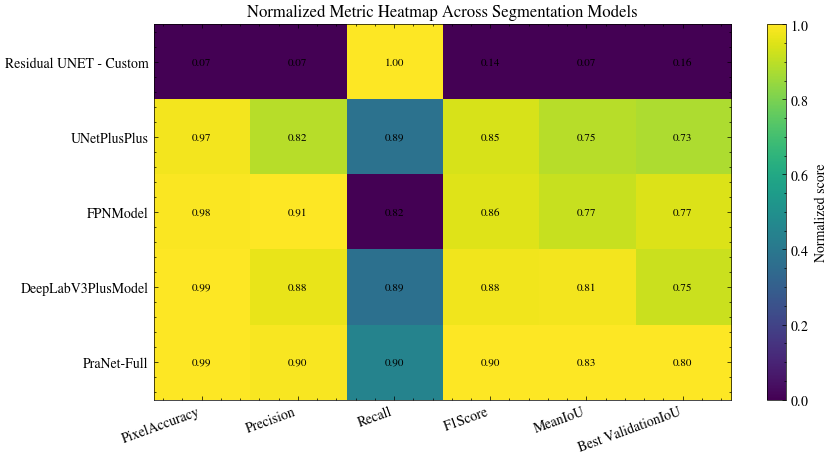

In [47]:
metrics = [
    "validationPixelAccuracy",
    "validationPrecision",
    "validationRecall",
    "validationF1Score",
    "validationMeanIoU",
    "bestValidationIoU",
]

heat = df.set_index("modelName")[metrics].copy()

# Optional: normalize per metric for visual comparison
heat_norm = (heat - heat.min()) / (heat.max() - heat.min())

fig, ax = plt.subplots(figsize=(9, 4.8))
im = ax.imshow(heat_norm.values, aspect="auto")

ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels(
    [m.replace("validation", "").replace("best", "Best ") for m in metrics],
    rotation=20,
    ha="right",
)
ax.set_yticks(np.arange(len(heat_norm.index)))
ax.set_yticklabels(heat_norm.index)

ax.set_title("Normalized Metric Heatmap Across Segmentation Models")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized score")

# annotate raw values
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "segmentation_models_metric_heatmap.png", bbox_inches="tight")
plt.show()

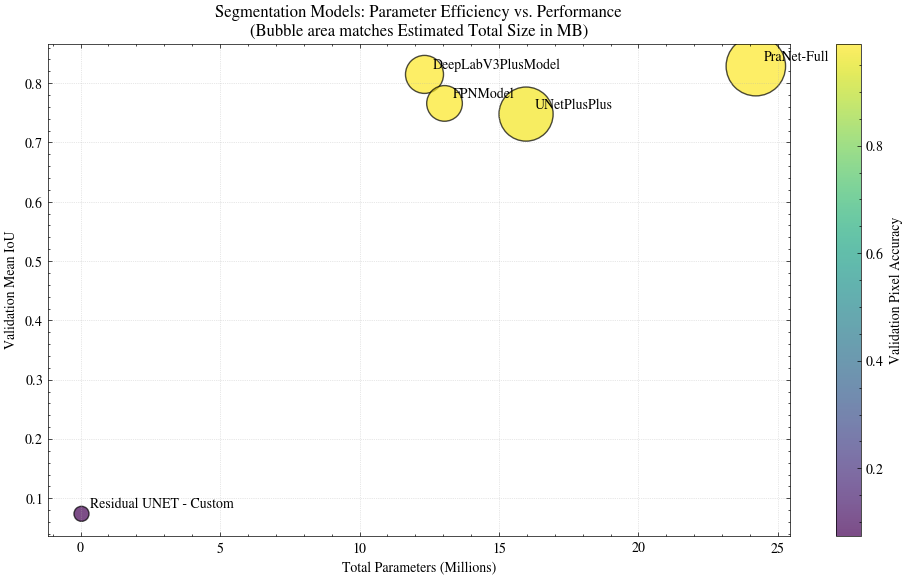

In [48]:
# 3. Plot 2: Efficiency Trade-off (Total Parameters vs. Performance)
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Bubble sizes correspond to Estimated Model Size (MB), color represents overall Pixel Accuracy
scatter2 = ax2.scatter(
    df_seg["totalParams"] / 1e6,
    df_seg["validationMeanIoU"],
    s=df_seg["estimatedTotalSizeMb"] * 5,
    c=df_seg["validationPixelAccuracy"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black",
)

# Label points with model names
for idx, row in df_seg.iterrows():
    ax2.annotate(
        row["modelName"],
        (row["totalParams"] / 1e6, row["validationMeanIoU"]),
        xytext=(6, 4),
        textcoords="offset points",
    )

ax2.set_xlabel("Total Parameters (Millions)")
ax2.set_ylabel("Validation Mean IoU")
ax2.set_title(
    "Segmentation Models: Parameter Efficiency vs. Performance\n(Bubble area matches Estimated Total Size in MB)"
)
cbar2 = fig2.colorbar(scatter2, ax=ax2)
cbar2.set_label("Validation Pixel Accuracy")
ax2.grid(linestyle=":", alpha=0.6)

plt.tight_layout()
fig2.savefig(OUTPUT_DIR / "segmentation_models_efficiency_tradeoff.png", dpi=300)
plt.show()

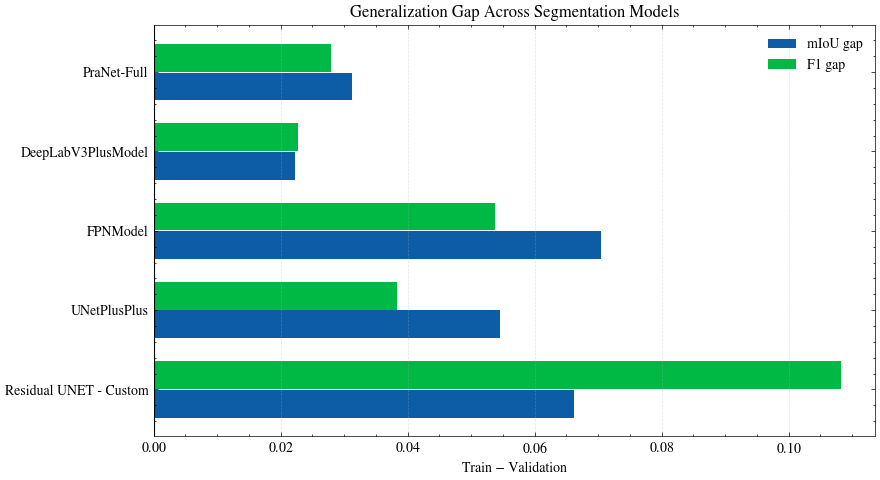

In [49]:
df["miou_gap"] = df["trainMeanIoU"] - df["validationMeanIoU"]
df["f1_gap"] = df["trainF1Score"] - df["validationF1Score"]

fig, ax = plt.subplots(figsize=(9, 5))

y = np.arange(len(df))
ax.barh(y - 0.18, df["miou_gap"], height=0.35, label="mIoU gap")
ax.barh(y + 0.18, df["f1_gap"], height=0.35, label="F1 gap")

ax.set_yticks(y)
ax.set_yticklabels(df["modelName"])
ax.set_xlabel("Train − Validation")
ax.set_title("Generalization Gap Across Segmentation Models")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "segmentation_models_generalization_gap.png", bbox_inches="tight")
plt.show(fig)

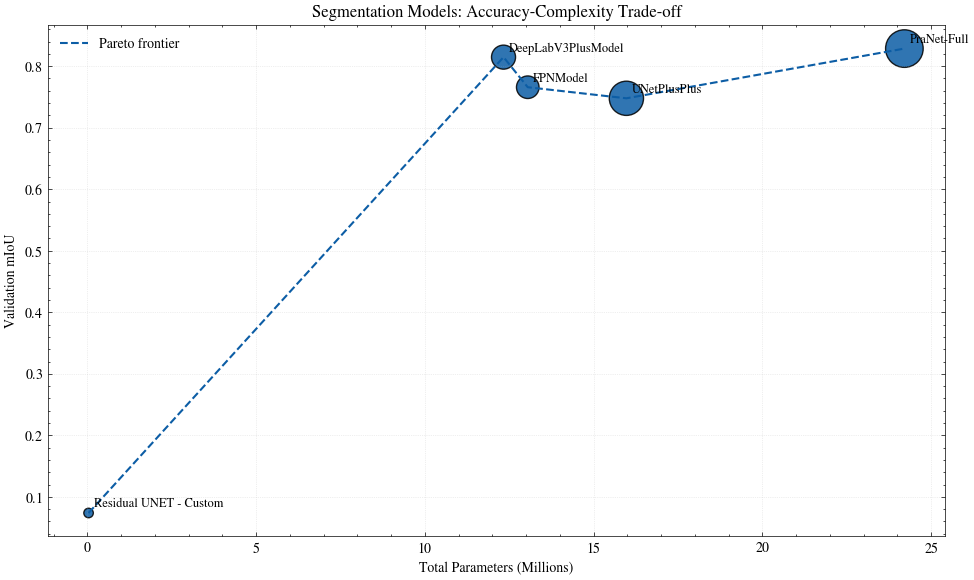

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = df_seg.copy()

plot_df["params_m"] = plot_df["totalParams"] / 1e6

sizes = plot_df["estimatedTotalSizeMb"] * 2

ax.scatter(
    plot_df["params_m"],
    plot_df["validationMeanIoU"],
    s=sizes,
    alpha=0.85,
    edgecolors="black"
)

for _, row in plot_df.iterrows():

    label = row["modelName"]

    ax.annotate(
        label,
        (row["params_m"], row["validationMeanIoU"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9
    )

pareto = plot_df.sort_values("params_m")

ax.plot(
    pareto["params_m"],
    pareto["validationMeanIoU"],
    "--",
    linewidth=1.5,
    label="Pareto frontier"
)

ax.set_xlabel("Total Parameters (Millions)")
ax.set_ylabel("Validation mIoU")
ax.set_title("Segmentation Models: Accuracy-Complexity Trade-off")

ax.grid(True, linestyle=":", alpha=0.4)

ax.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "segmentation_models_pareto_tradeoff.png",
    dpi=300
)

plt.show()

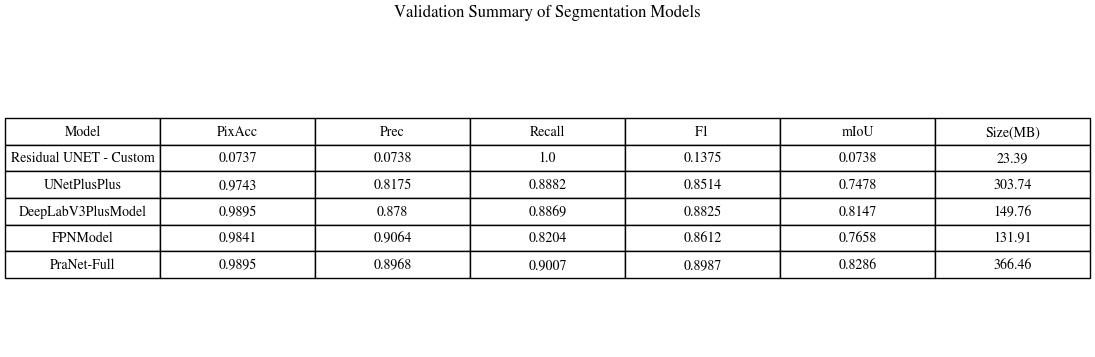

In [51]:
summary = df_seg[
    [
        "modelName",
        "validationPixelAccuracy",
        "validationPrecision",
        "validationRecall",
        "validationF1Score",
        "validationMeanIoU",
        "estimatedTotalSizeMb"
    ]
].copy()

summary.columns = [
    "Model",
    "PixAcc",
    "Prec",
    "Recall",
    "F1",
    "mIoU",
    "Size(MB)"
]

fig, ax = plt.subplots(
    figsize=(14, 4)
)

ax.axis("off")

table = ax.table(
    cellText=summary.round(4).values,
    colLabels=summary.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

plt.title(
    "Validation Summary of Segmentation Models",
    pad=20
)

plt.savefig(
    OUTPUT_DIR / "segmentation_models_summary_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

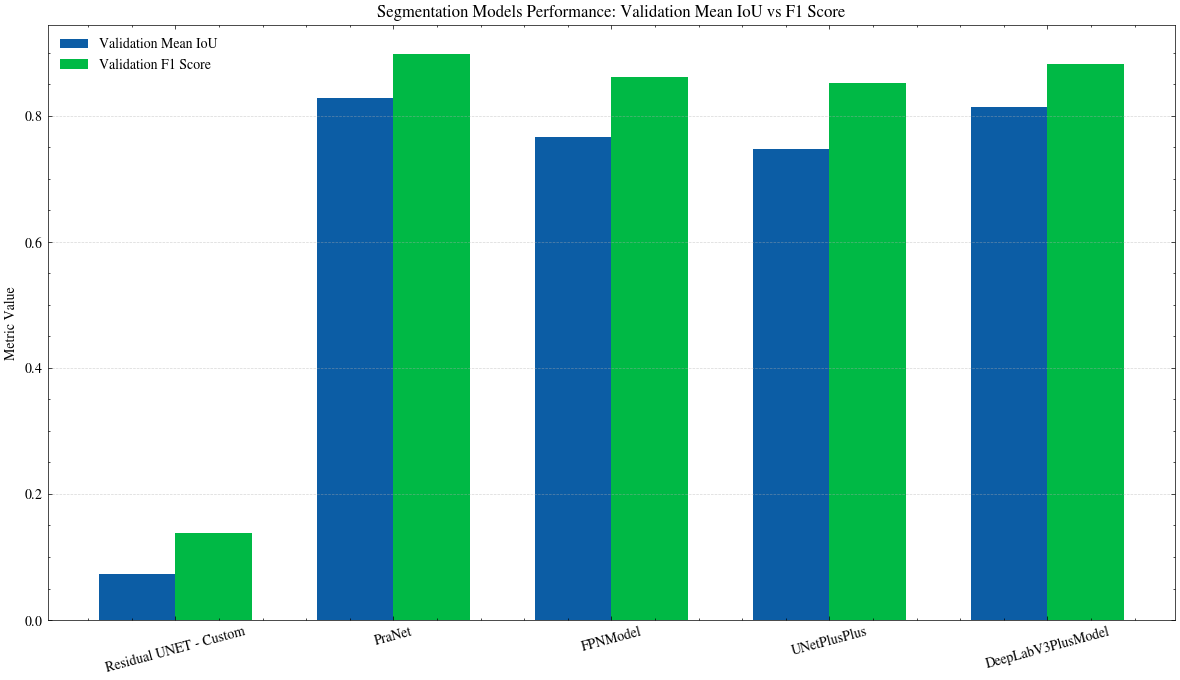

In [52]:
models = [
    "Residual UNET - Custom",
    "PraNet-Full",
    "FPNModel",
    "UNetPlusPlus",
    "DeepLabV3PlusModel"
]

plot_df = (
    df_seg
    .set_index("modelName")
    .loc[models]
    .reset_index()
)

x = np.arange(len(plot_df))

width = 0.35

fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.bar(
    x - width/2,
    plot_df["validationMeanIoU"],
    width,
    label="Validation Mean IoU"
)

ax.bar(
    x + width/2,
    plot_df["validationF1Score"],
    width,
    label="Validation F1 Score"
)

ax.set_xticks(x)

ax.set_xticklabels(
    [
        "Residual UNET - Custom",
        "PraNet",
        "FPNModel",
        "UNetPlusPlus",
        "DeepLabV3PlusModel"
    ],
    rotation=15
)

ax.set_ylabel("Metric Value")

ax.set_title(
    "Segmentation Models Performance: Validation Mean IoU vs F1 Score"
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "segmentation_models_performance_comparison.png",
    dpi=300
)

plt.show()